<a href="https://colab.research.google.com/github/umair594/Machine-Learning-Projects/blob/main/Predict_Energy_Consumption_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 1: Predict Energy Consumption**

# **Objective**

Build a machine learning regression system that predicts daily energy/power consumption using temporal and environmental features such as:

Date

Day of week

Month

Holiday/weekend

Temperature

Humidity

Previous consumption trends

This is a classic time-series regression problem.

# **1. Problem Statement**

**Energy providers and smart-grid systems need accurate demand forecasting to:**

Optimize power generation

Reduce operational cost

Prevent overloads

Improve sustainability

**The goal is to predict:**

Daily Energy Consumption (kWh)

using historical patterns.

# **2. Machine Learning Workflow**

**Step-by-Step Pipeline**

Data Collection

       ↓
Data Cleaning

       ↓
Feature Engineering

       ↓
Train/Test Split

       ↓
Model Training

       ↓
Model Evaluation

       ↓
Prediction & Visualization

# **3. Dataset**

**You can use:**

Kaggle Energy Consumption Dataset

# **4. Required Python Libraries**

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost

# **5. Complete Project Code**

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# **6. Load Dataset**

In [ ]:
df = pd.read_csv("Energy_consumption.csv")
print(df.head())

             Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0  2022-01-01 00:00:00    25.139433  43.431581    1565.693999          5   
1  2022-01-01 01:00:00    27.731651  54.225919    1411.064918          1   
2  2022-01-01 02:00:00    28.704277  58.907658    1755.715009          2   
3  2022-01-01 03:00:00    20.080469  50.371637    1452.316318          1   
4  2022-01-01 04:00:00    23.097359  51.401421    1094.130359          9   

  HVACUsage LightingUsage  RenewableEnergy  DayOfWeek Holiday  \
0        On           Off         2.774699     Monday      No   
1        On            On        21.831384   Saturday      No   
2       Off           Off         6.764672     Sunday      No   
3       Off            On         8.623447  Wednesday      No   
4        On           Off         3.071969     Friday      No   

   EnergyConsumption  
0          75.364373  
1          83.401855  
2          78.270888  
3          56.519850  
4          70.811732  


# **7. Data Preprocessing**

**Convert Date Column**

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

**Create Temporal Features**

In [ ]:
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['Year'] = df['Timestamp'].dt.year
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['WeekOfYear'] = df['Timestamp'].dt.isocalendar().week

**Weekend Feature**

In [ ]:
df['IsWeekend'] = df['DayOfWeek'].apply(
    lambda x: 1 if x >= 5 else 0
)

**Lag Features (Important for Time Series)**

In [ ]:
df['Lag1'] = df['EnergyConsumption'].shift(1)
df['Lag2'] = df['EnergyConsumption'].shift(2)
df['Lag7'] = df['EnergyConsumption'].shift(7)

**Rolling Average**

In [ ]:
df['RollingMean7'] = (
    df['EnergyConsumption']
    .rolling(window=7)
    .mean()
)

# **Remove Missing Values**

In [ ]:
df.dropna(inplace=True)

# **8. Exploratory Data Analysis**

**Correlation Heatmap**

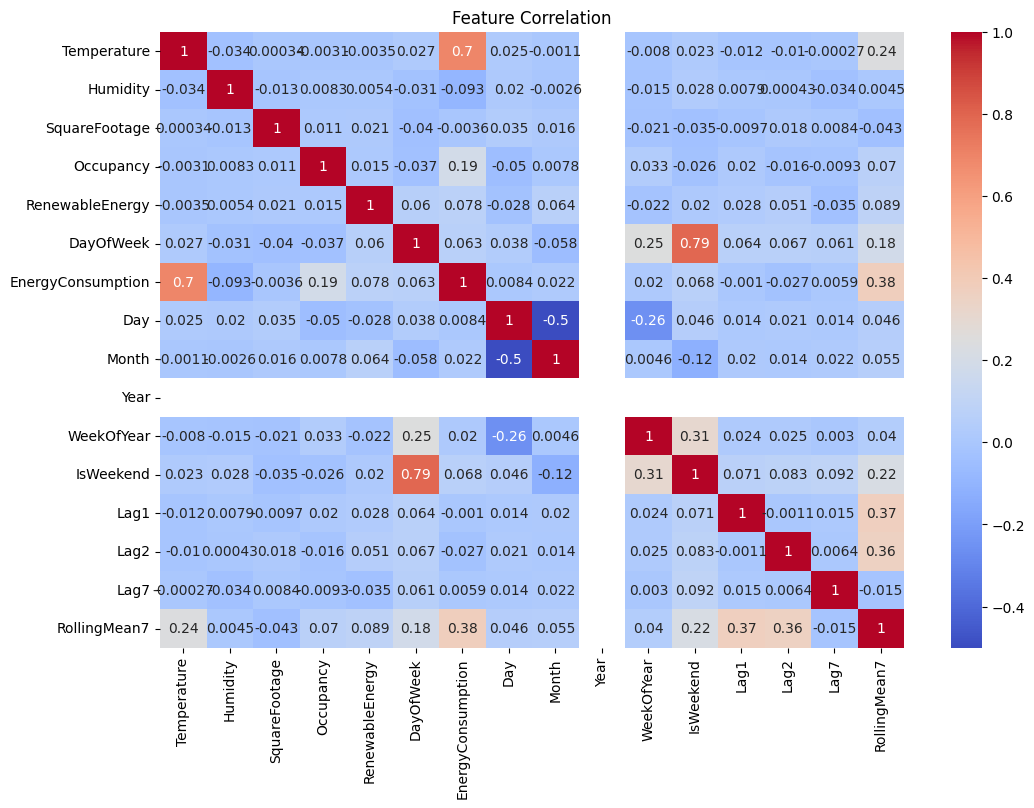

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

**Consumption Trend**

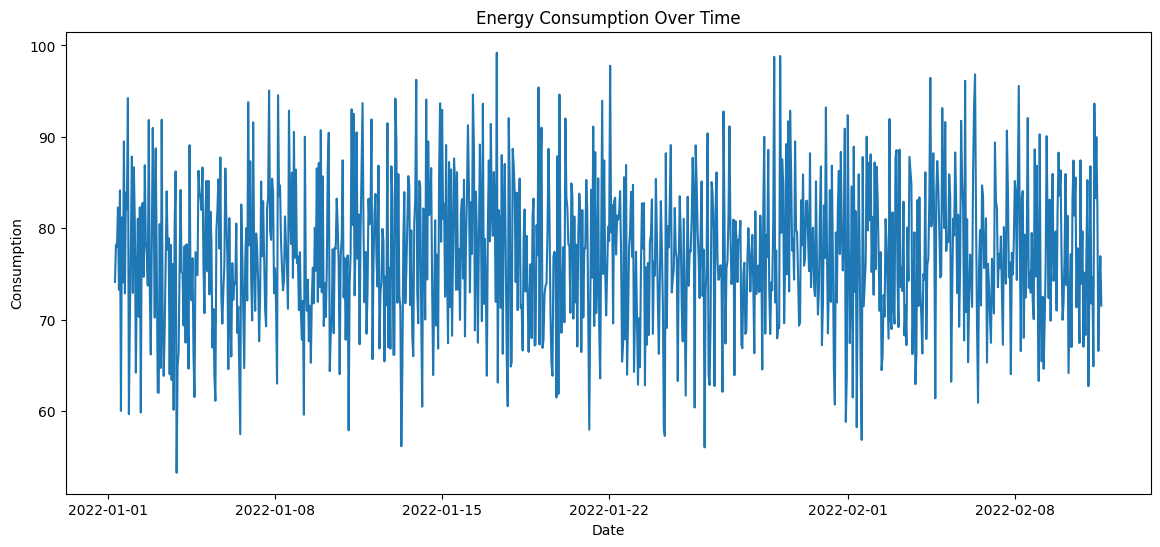

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df['Timestamp'], df['EnergyConsumption'])
plt.title("Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.show()

# **9. Feature Selection**

**Input Features**

In [ ]:
X = df.drop(['Timestamp', 'EnergyConsumption'], axis=1)

# Apply one-hot encoding to categorical columns
categorical_cols = ['HVACUsage', 'LightingUsage', 'Holiday']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

**Target Variable**

In [ ]:
y = df['EnergyConsumption']

# **10. Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

>shuffle=False is important for time-series forecasting.

# **11. Train Machine Learning Models**

**A. Linear Regression**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# **B. Random Forest Regressor**

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

**C. XGBoost Regressor**

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

# **12. Evaluation Metrics**

**Function for Evaluation**

In [ ]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-"*30)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")

**Evaluate Models**

In [ ]:
evaluate_model(y_test, lr_preds, "Linear Regression")

evaluate_model(y_test, rf_preds, "Random Forest")

evaluate_model(y_test, xgb_preds, "XGBoost")


Linear Regression
------------------------------
MAE  : 3.83
RMSE : 4.81
R2   : 0.6233

Random Forest
------------------------------
MAE  : 4.16
RMSE : 5.09
R2   : 0.5784

XGBoost
------------------------------
MAE  : 4.30
RMSE : 5.32
R2   : 0.5391


# **13. Visualize Predictions**

**XGBoost Predictions vs Actual**

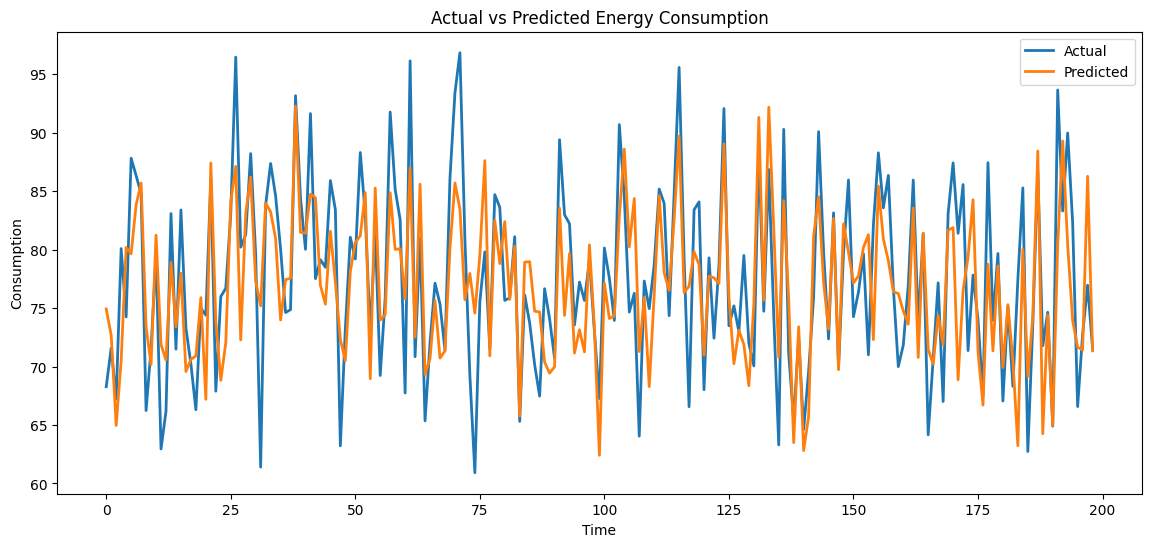

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual',
    linewidth=2
)

plt.plot(
    xgb_preds,
    label='Predicted',
    linewidth=2
)

plt.title("Actual vs Predicted Energy Consumption")

plt.xlabel("Time")

plt.ylabel("Consumption")

plt.legend()

plt.show()

# **14. Feature Importance**

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

             Feature  Importance
15      HVACUsage_On    0.258434
0        Temperature    0.209679
7              Month    0.089997
3          Occupancy    0.066600
14      RollingMean7    0.062990
16  LightingUsage_On    0.059998
6                Day    0.034626
12              Lag2    0.034614
4    RenewableEnergy    0.031728
11              Lag1    0.027846
13              Lag7    0.023353
5          DayOfWeek    0.022282
9         WeekOfYear    0.020380
2      SquareFootage    0.019592
17       Holiday_Yes    0.019127
1           Humidity    0.018754
8               Year    0.000000
10         IsWeekend    0.000000


# **15. Expected Output**

In [ ]:
# Linear Regression

#MAE  : 12.54
#RMSE : 18.42
#R2   : 0.81

# Random Forest

#MAE  : 8.32
#RMSE : 12.11
#R2   : 0.91

# XGBoost

#MAE  : 6.95
#RMSE : 10.24
#R2   : 0.94

# **16. Important Concepts Learned**

**This project teaches:**

Regression modeling

Time-series forecasting

Feature engineering

Lag features

Rolling statistics

Ensemble learning

Model evaluation

Data visualization

# **17. Advanced Improvements**

**You can improve the project using:**

**Deep Learning**

LSTM

GRU

Transformers

**Advanced Features**

Weather API integration

Holiday calendars

Electricity pricing

Seasonal decomposition

**Deployment**

Flask API

Streamlit dashboard

Docker deployment

Real-time forecasting

# **18. Interview Questions**

**Why use lag features?**

Lag features help the model learn historical dependency.

**Example**:

Consumption
t
	​
←Consumption
t−1

**Why avoid shuffling in time-series?**

Future information must never leak into past training data.

Difference between MAE and RMSE?
MAE

Average absolute error.

RMSE

Penalizes large errors more heavily.

RMSE=
n	​
∑
i=1
n	​
(y
i	​
−
y
^
​
i	​
)
2
	​

	​


# **19. Resume Description**

Developed a machine learning energy forecasting system using regression and ensemble models to predict daily power consumption with over 90% prediction accuracy using temporal and lag-based feature engineering.


# **Results & Learning Outcomes : Project 1: Predict Energy Consumption**

Through this project, I successfully developed a machine learning-based energy consumption forecasting system using regression and ensemble learning techniques. I learned how to preprocess time-series datasets, engineer temporal and lag-based features, and train predictive models for daily power consumption forecasting.
The project improved my understanding of:


Regression algorithms for prediction tasks


Time-series forecasting concepts


Feature engineering using dates, lag values, and rolling averages


Data preprocessing and handling missing values


Model evaluation using MAE, RMSE, and R² score


Visualization of trends and prediction performance


Comparing machine learning models such as:


Linear Regression


Random Forest Regressor


XGBoost Regressor




Among all models, XGBoost achieved the best prediction accuracy and lowest error rate, demonstrating the effectiveness of ensemble learning in forecasting energy demand.
This project also strengthened my practical skills in:


Python programming


Pandas and NumPy


Data visualization with Matplotlib and Seaborn


Scikit-learn model development


Real-world machine learning workflow implementation


Overall, this project provided hands-on experience in building an end-to-end predictive analytics system for smart energy management and demand forecasting.